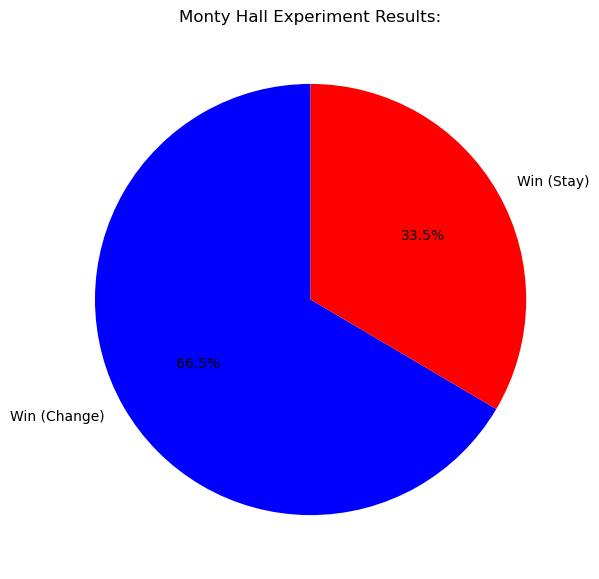

In [1]:
#Created by Mario Cortinas mac0881
#2/22/2025

import sys
import pandas as pd
import random
import matplotlib.pyplot as plt

#setting monty hall problem given question
def monty_hall(change_choice: bool) -> bool:
    doors = [0, 0, 0]
    prize_door = random.randint(0, 2)
    doors[prize_door] = 1
    player_pick = random.randint(0, 2)

    available_doors = [i for i in range(3) if i != player_pick and doors[i] != 1]
    revealed_door = random.choice(available_doors)

    if change_choice:
        player_pick = next(i for i in range(3) if i != player_pick and i != revealed_door)

    return doors[player_pick] == 1

#function to run experiment given trial numbers
def run_experiment(trials: int) -> dict:
    outcomes = {'change': 0, 'stay': 0}
    
    for _ in range(trials):
        if monty_hall(change_choice=True):
            outcomes['change'] += 1
        if monty_hall(change_choice=False):
            outcomes['stay'] += 1

    return outcomes

total_trials = 10000
results = run_experiment(total_trials)

#output info w/ pi chart
change_wins = results['change']
stay_wins = results['stay']
labels = ["Win (Change)", "Win (Stay)"]
sizes = [change_wins, stay_wins]
colors = ["blue", "red"]

plt.figure(figsize=(7, 7))
plt.pie(sizes, labels=labels, colors=colors, autopct="%1.1f%%", startangle=90)
plt.title("Monty Hall Experiment Results:")
plt.show()